<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/CNN_Computer_Vision/4_Anotacao_Automatica_modeloPreTreinado_superanimal_quadruped.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Extrai arquivos zipados
!unzip -q /content/videos.zip -d /content/

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install --pre deeplabcut

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━

1. Cria a Estrutura de Pastas e Configuração
Ele cria automaticamente no seu Drive toda a hierarquia de pastas necessária (dlc-models, labeled-data, training-datasets). Além disso, ele gera o arquivo config.yaml já preenchido com a lista de pontos (labels) que o modelo superanimal conhece.

2. Importa o "Cérebro" do SuperAnimal
Em vez de começar com uma rede "burra" que não sabe o que é um animal, este comando baixa pesos de uma rede que já foi treinada em milhares de quadrúpedes.

Por que isso importa para você: Essa rede já aprendeu a diferenciar a anatomia de uma pata dianteira de uma traseira em diversos ângulos. Isso reduz drasticamente os erros de inversão que você teve no primeiro teste.

3. Mapeia seus Vídeos
Ele registra os 10 vídeos que você indicou como a fonte de dados do projeto e faz uma cópia deles para dentro da pasta do projeto no Drive (garantindo que, se você apagar os arquivos temporários do Colab, os vídeos do projeto continuem seguros).

Created "/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos"
Created "/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/labeled-data"
Created "/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/training-datasets"
Created "/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/dlc-models"
Copying the videos
/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/2.mp4
/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/4.mp4
/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/1.mp4
/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/5.mp4
/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/6.mp4
/content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/10.mp4
/content/drive/MyDrive/DLC_Projects/Analise

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


superanimal_quadruped_fasterrcnn_resnet5(…):   0%|          | 0.00/173M [00:00<?, ?B/s]

Loading.... superanimal_quadruped_hrnet_w32


superanimal_quadruped_hrnet_w32.pt:   0%|          | 0.00/118M [00:00<?, ?B/s]

...

Duration of video [s]: 4.6, recorded with 15.0 fps!
Overall # of frames: 69 with cropped frame dimensions: 2208 1242
Generating frames and creating video.


100%|██████████| 69/69 [00:04<00:00, 16.61it/s]


Starting to process video: /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/2.mp4
Loading /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/2.mp4 and data.
Duration of video [s]: 3.07, recorded with 15.0 fps!
Overall # of frames: 46 with cropped frame dimensions: 2208 1242
Generating frames and creating video.


100%|██████████| 46/46 [00:01<00:00, 23.10it/s]


Analyzing all the videos in the directory...
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/7.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/3.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/4.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/1.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/9.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/10.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/5.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/8.mp4 and data.
Loading  /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03

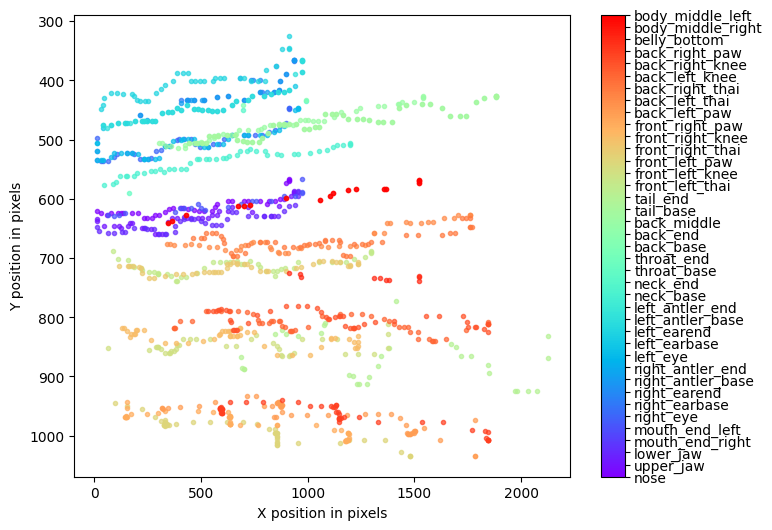

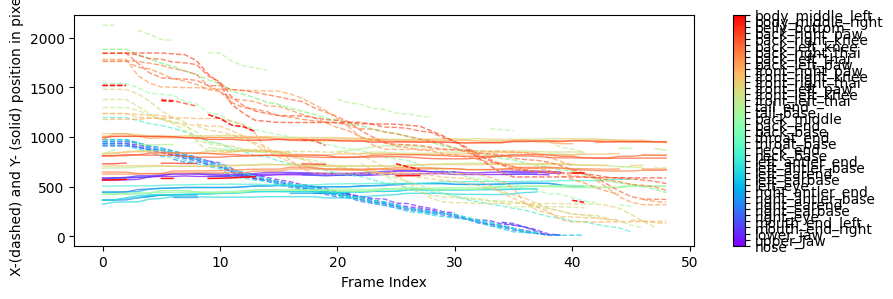

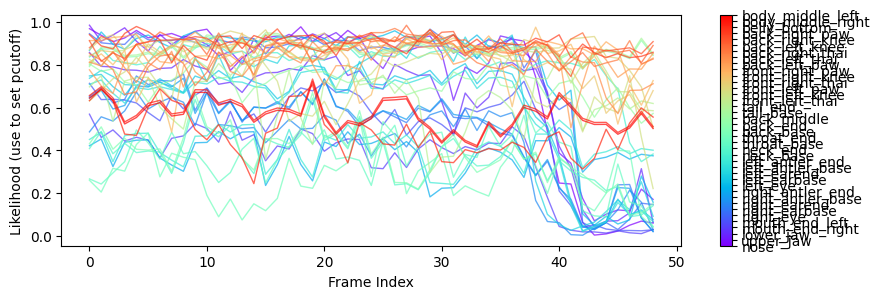

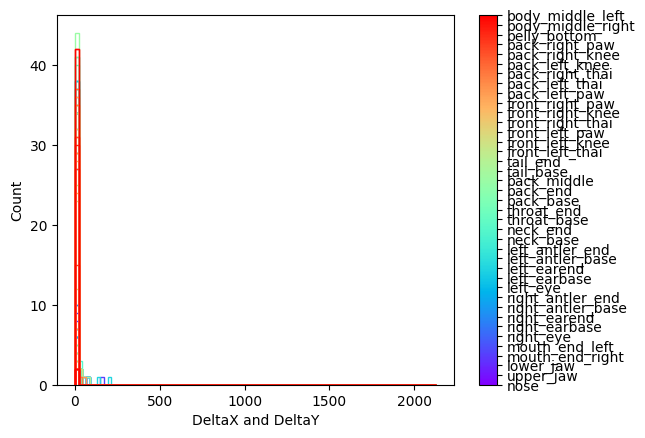

In [5]:
import deeplabcut
import os

# Caminho da pasta onde você colocou os vídeos no Colab
folder_path = '/content/videos'
video_path = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.mp4')]

config_path = deeplabcut.create_pretrained_project(
    project='AnaliseMarcha_Vitoria',
    experimenter='Vitoria',
    videos=video_path,
    model='superanimal_quadruped',
    working_directory='/content/drive/MyDrive/DLC_Projects',
    copy_videos=True
)

In [9]:
# Se o config_path for uma tupla, pegamos apenas a primeira parte (o caminho real)
if isinstance(config_path, tuple):
    config_path = config_path[0]

# Agora a extração vai funcionar sem erro de 'tuple'
deeplabcut.extract_frames(config_path, mode='automatic', algo='uniform', userfeedback=False)

Config file read successfully.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 3.07  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 4.13  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 5.2  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 3.73  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 3.27  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 8.53  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 4.6  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 3.6  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 2.93  seconds.
Extracting frames 

[False, False, False, False, False, False, False, False, False, False]

In [11]:
# Aponta para onde os vídeos e os arquivos .h5 realmente estão
drive_video_folder = os.path.join(os.path.dirname(config_path), 'videos')
video_list_drive = [os.path.join(drive_video_folder, f) for f in os.listdir(drive_video_folder) if f.endswith('.mp4')]

In [12]:
# Agora ele vai achar os arquivos .h5 e filtrar
deeplabcut.filterpredictions(config_path, video_list_drive, videotype='mp4', filtertype='arima')

Filtering with arima model /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/2.mp4
Data from 2 were already filtered. Skipping...
Filtering with arima model /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/4.mp4
Data from 4 were already filtered. Skipping...
Filtering with arima model /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/1.mp4
Data from 1 were already filtered. Skipping...
Filtering with arima model /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/5.mp4
Data from 5 were already filtered. Skipping...
Filtering with arima model /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/6.mp4
Data from 6 were already filtered. Skipping...
Filtering with arima model /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/10.mp4
Data from 10 were already filtered. Skipping...
Filtering with

In [13]:
# Agora sim, cria os vídeos anotados
deeplabcut.create_labeled_video(config_path, video_list_drive, videotype='mp4', draw_skeleton=True, filtered=True)

Starting to process video: /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/2.mp4
Loading /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/2.mp4 and data.
Starting to process video: /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/1.mp4
Loading /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/1.mp4 and data.
Labeled video already created. Skipping...
Starting to process video: /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/4.mp4
Loading /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/4.mp4 and data.
Labeled video already created. Skipping...
Starting to process video: /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/5.mp4
Loading /content/drive/MyDrive/DLC_Projects/AnaliseMarcha_Vitoria-Vitoria-2026-03-16/videos/5.mp4 and data.
Labeled video 

[None, None, None, None, None, None, None, None, None, None]